In [5]:
# uncomment to dowload packages (need to do only once)
# using Pkg
# Pkg.add("BifurcationKit");Pkg.add("Plots");Pkg.add("SparseArrays");Pkg.add("DifferentialEquations")
#import Pkg; Pkg.add("NLsolve")
# import Pkg; Pkg.add("LaTeXStrings")
# import Pkg; Pkg.add("CairoMakie")

𝒱       γbar=c·𝒱  (O(𝒱))      γbar=c  (O(1))
20      0.007                 0.1396
50      0.0028                0.1405
100     0.0014                0.1412
200     0.0007                0.1408
400     0.0004                0.1405


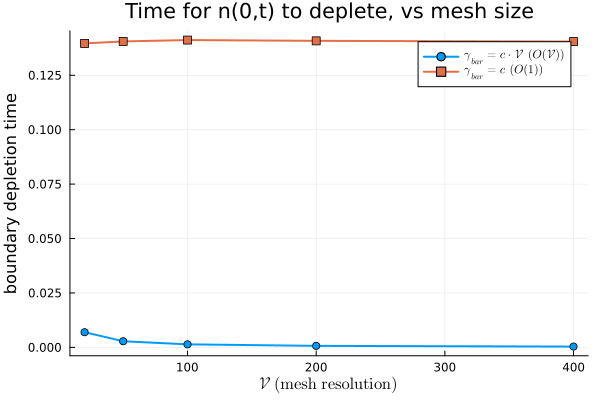

In [10]:
using DifferentialEquations
using OrdinaryDiffEqRosenbrock
using Plots
using LaTeXStrings

# ============================================================
# PARAMETERS THAT DON'T DEPEND ON MESH RESOLUTION 𝒱
# ============================================================

const 𝒦        = 50.0
const r        = 0.6078290935711611
const αr       = 0.04
const ηbar     = 0.01
const λ1       = 0.8
const Vconst   = 50.0     # constant virus level V (this is NOT the mesh size)
const N0_total = 25.0

# ============================================================
# MODEL — now parametric in Vcomp (mesh size) and γbar,
# passed in through the ODE `p` argument instead of being globals.
# ============================================================

function structured_model!(du, u, p, t)
    γbar, Vcomp = p

    N  = @view u[1:(Vcomp+1)]
    ρN = sum(N)

    η(i) = ηbar * i * (1 - i/Vcomp)
    γ(i) = γbar * (1 - i/Vcomp)

    # N_0
    du[1] = r*N[1]*(1 - ρN/𝒦) - γ(0)*Vconst*N[1]

    # N_i, i = 1,...,Vcomp
    for i in 1:Vcomp
        Ni, Nim1 = N[i+1], N[i]

        growth = r*(1 - αr*i/Vcomp)*Ni*(1 - ρN/𝒦)
        phen   = η(i-1)*Nim1 - η(i)*Ni
        viral  = Vconst*(γ(i-1)*Nim1 - γ(i)*Ni)
        death  = λ1*(i/Vcomp)*Ni

        du[i+1] = growth + phen + viral - death
    end

    return nothing
end

function build_u0(Vcomp)
    N0 = zeros(Vcomp + 1)
    N0[1] = N0_total          # all initial mass concentrated at z = 0
    return N0
end

# ============================================================
# BOUNDARY DEPLETION TIME
#
# n(0,t) = N_0(t) * Vcomp  is the continuum boundary density.
# We record the first saved time at which it drops below
# `frac` * its initial value.
# ============================================================

function boundary_depletion_time(γbar, Vcomp; tmax=50.0, frac=0.001)
    u0   = build_u0(Vcomp)
    prob = ODEProblem(structured_model!, u0, (0.0, tmax), (γbar, Vcomp))
    sol  = solve(prob, Rodas5(); reltol=1e-8, abstol=1e-10)

    density0_t   = sol[1, :] .* Vcomp     # n(0, t) at every saved timepoint
    density0_init = N0_total * Vcomp
    thresh        = frac * density0_init

    idx = findfirst(x -> x < thresh, density0_t)
    return idx === nothing ? NaN : sol.t[idx]   # NaN => never dropped within tmax
end

# ============================================================
# RUN THE CONVERGENCE STUDY
# ============================================================

Vcomps = (20, 50, 100, 200, 400)
c      = 1.0     # base infection-rate coefficient — tune this to your PDE's constant

tdep_a = Float64[]   # family (a): γbar = c * Vcomp   →  O(𝒱) scaling
tdep_b = Float64[]   # family (b): γbar = c           →  O(1) scaling

for Vcomp in Vcomps
    push!(tdep_a, boundary_depletion_time(c*Vcomp, Vcomp))
    push!(tdep_b, boundary_depletion_time(c,       Vcomp))
end

println(rpad("𝒱", 8), rpad("γbar=c·𝒱  (O(𝒱))", 22), "γbar=c  (O(1))")
for (k, Vcomp) in enumerate(Vcomps)
    println(rpad(Vcomp, 8), rpad(round(tdep_a[k], digits=4), 22), round(tdep_b[k], digits=4))
end

# ============================================================
# PLOT: depletion time vs mesh size, both families on one axis
# ============================================================

p = plot(collect(Vcomps), tdep_a;
    marker = :circle, lw = 2,
    label  = L"\gamma_{bar} = c\cdot\mathcal{V} \;\; (O(\mathcal{V}))",
    xlabel = L"\mathcal{V}\ \mathrm{(mesh\ resolution)}",
    ylabel = "boundary depletion time",
    title  = "Time for n(0,t) to deplete, vs mesh size")

plot!(p, collect(Vcomps), tdep_b;
    marker = :square, lw = 2,
    label  = L"\gamma_{bar} = c \;\; (O(1))")

savefig(p, "boundary_depletion_convergence.png")
display(p)

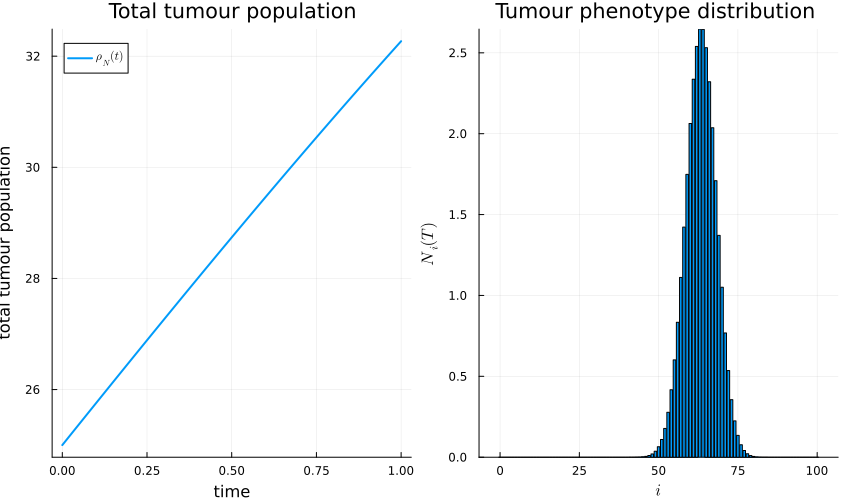

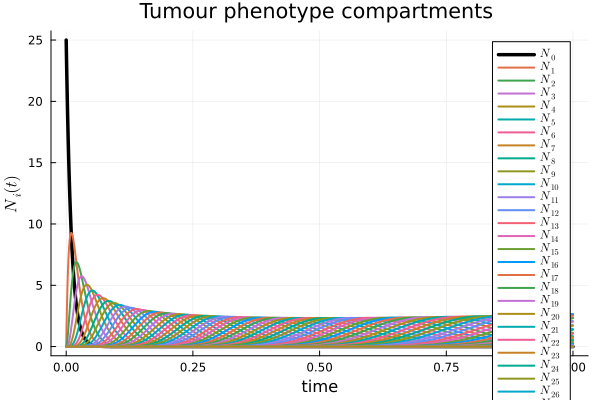

Final ρN = 32.26988031382292


In [ ]:
using DifferentialEquations
using OrdinaryDiffEqRosenbrock
using Plots
using LaTeXStrings

# ============================================================
# PARAMETERS
# ============================================================

const r    = 0.6078290935711611   
                                  
const αr   = 0.04                 
                                  

const 𝒱    = 100

const 𝒦    = 50.0
const ρmax = 𝒦

const ηbar = 0.01
const γbar = 100
const λ1   = 0.#0.8
const δV   = 0.0#0.01   # unused now that V is constant, kept for reference
const V    = 1

# ============================================================
# STRUCTURED ODE SYSTEM  (tumour compartments only, V held constant)
# ============================================================

function structured_model!(du, u, params, t)

    # --------------------------------------------------------
    # STATE VARIABLES
    
    # --------------------------------------------------------

    N = @view u[1:(𝒱+1)]          

    firstNindex = 1               

    # --------------------------------------------------------
    # TOTAL POPULATION
    # --------------------------------------------------------

    ρN = sum(N)

    # ========================================================
    # HELPER FUNCTIONS
    # ========================================================

    # Tumour phenotype transition
    η(i) = ηbar * i * (1 - i/𝒱)

    # Viral infection rate
    γ(i) = γbar * (1 - i/𝒱)

    # ========================================================
    # TUMOUR EQUATIONS
    # ========================================================

    # N_0
    du[firstNindex] =
        r * N[1] * (1 - ρN/𝒦) -
        γ(0)*V*N[1]
     

    # N_i, i = 1,...,𝒱
    for i in 1:𝒱
        Ni   = N[i+1]
        Nim1 = N[i]

        growth = r * (1 - αr*i/𝒱) * Ni * (1 - ρN/𝒦)

        phenotype_transition = η(i-1)*Nim1 - η(i)*Ni

        viral_transition = V * (γ(i-1)*Nim1 - γ(i)*Ni)

        viral_production_death = λ1 * (i/𝒱) * Ni

        du[firstNindex + i] =
            growth +
            phenotype_transition +
            viral_transition -
            viral_production_death
    end

    return nothing
end

# ============================================================
# INITIAL CONDITIONS
# ============================================================

function build_u0(; N0_total=25.0)
    N = zeros(𝒱+1)
    N[1] = N0_total
    return N                        
end


# ============================================================
# SIMULATE
# ============================================================

u0    = build_u0()
tspan = (0.0, 1.)

prob = ODEProblem(structured_model!, u0, tspan)
sol  = solve(prob, Rodas5(); reltol=1e-8, abstol=1e-10)

# --------------------------------------------------------
# Aggregate trajectories
# --------------------------------------------------------

ts   = sol.t
ρN_t = [sum(sol.u[k][1:(𝒱+1)]) for k in eachindex(ts)]

p1 = plot(ts, ρN_t; label=L"\rho_N(t)", xlabel="time", ylabel="total tumour population",
          title="Total tumour population", lw=2)

# --------------------------------------------------------
# Final phenotype distribution
# --------------------------------------------------------

Nfinal = sol.u[end][1:(𝒱+1)]        

p2 = bar(0:𝒱, Nfinal; label=false, xlabel=L"i", ylabel=L"N_i(T)",
         title="Tumour phenotype distribution ")

# --------------------------------------------------------
# N_0, N_1, ..., N_𝒱 trajectories over time, all on one plot
# --------------------------------------------------------

N_traj = sol[1:(𝒱+1), :]           

p5 = plot(xlabel="time", ylabel=L"N_i(t)",
          title="Tumour phenotype compartments ")
          plot!(p5, ts, N_traj[1, :]; label=L"N_%$0", lw=3.5, color="black")
for i in 1:𝒱
    plot!(p5, ts, N_traj[i+1, :]; label=L"N_{%$i}", lw=2.0)
end


fig = plot(p1, p2; layout=(1,2), size=(850, 500))

savefig(fig, "structured_model_summary.png")
display(fig)

savefig(p5, "N_phenotype_trajectories.png")
display(p5)

println("Final ρN = ", ρN_t[end])

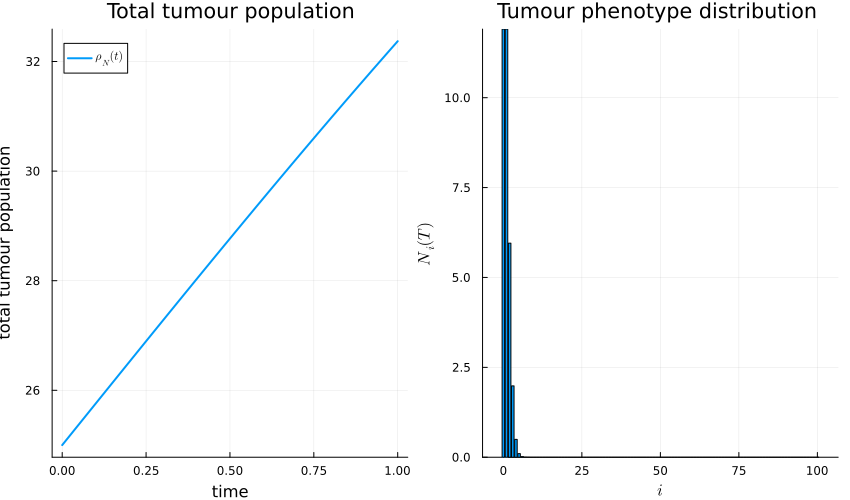

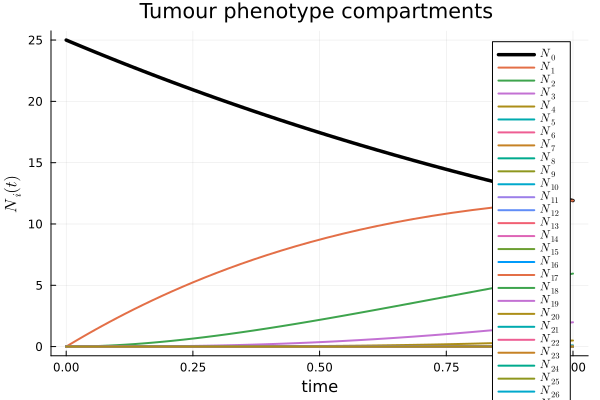

Final ρN = 32.3708841662073


In [ ]:
using DifferentialEquations
using OrdinaryDiffEqRosenbrock
using Plots
using LaTeXStrings

# ============================================================
# PARAMETERS
# ============================================================

const r    = 0.6078290935711611   
const αr   = 0.04                

const 𝒱    = 100

const 𝒦    = 50.0
const ρmax = 𝒦

const ηbar = 0.01
const γbar = 1
const λ1   = 0.#0.8
const δV   = 0.0#0.01   
const V    = 1

# ============================================================
# STRUCTURED ODE SYSTEM  (tumour compartments only, V held constant)
# ============================================================

function structured_model!(du, u, params, t)

    # --------------------------------------------------------
    # STATE VARIABLES
    # --------------------------------------------------------

    N = @view u[1:(𝒱+1)]          

    firstNindex = 1                 

    # --------------------------------------------------------
    # TOTAL POPULATION
    # --------------------------------------------------------

    ρN = sum(N)

    # ========================================================
    # HELPER FUNCTIONS
    # ========================================================

    # Tumour phenotype transition
    η(i) = ηbar * i * (1 - i/𝒱)

    # Viral infection rate
    γ(i) = γbar * (1 - i/𝒱)

    # ========================================================
    # TUMOUR EQUATIONS
    # ========================================================

    # N_0
    du[firstNindex] =
        r * N[1] * (1 - ρN/𝒦) -
        γ(0)*V*N[1]
        # FIX: dropped the `- killing0*N[1]` term. killing0 depended on
        # δN and the (now removed) C compartments — there's no CAR-T
        # killing left in this tumour-only version. If you want a
        # constant background death/clearance term here instead, add it
        # back explicitly.

    # N_i, i = 1,...,𝒱
    for i in 1:𝒱
        Ni   = N[i+1]
        Nim1 = N[i]

        growth = r * (1 - αr*i/𝒱) * Ni * (1 - ρN/𝒦)

        phenotype_transition = η(i-1)*Nim1 - η(i)*Ni

        viral_transition = V * (γ(i-1)*Nim1 - γ(i)*Ni)

        viral_production_death = λ1 * (i/𝒱) * Ni

        du[firstNindex + i] =
            growth +
            phenotype_transition +
            viral_transition -
            viral_production_death
    end

    return nothing
end

# ============================================================
# INITIAL CONDITIONS
# ============================================================

function build_u0(; N0_total=25.0)
    N = zeros(𝒱+1)
    N[1] = N0_total
    return N                        # FIX: vcat(N) with nothing else to
                                     # concatenate was a no-op; N alone
                                     # is already the full state vector.
end


# ============================================================
# SIMULATE
# ============================================================

u0    = build_u0()
tspan = (0.0, 1.)

prob = ODEProblem(structured_model!, u0, tspan)
sol  = solve(prob, Rodas5(); reltol=1e-8, abstol=1e-10)

# --------------------------------------------------------
# Aggregate trajectories
# --------------------------------------------------------

ts   = sol.t
ρN_t = [sum(sol.u[k][1:(𝒱+1)]) for k in eachindex(ts)]

p1 = plot(ts, ρN_t; label=L"\rho_N(t)", xlabel="time", ylabel="total tumour population",
          title="Total tumour population", lw=2)
# FIX: dropped the ρC_t series (C no longer exists) and the earlier
# `100*ρN_t` rescale, which was only there to put ρN on a comparable
# scale to ρC. Plot ρN on its own scale now.

# --------------------------------------------------------
# Final phenotype distribution
# --------------------------------------------------------

Nfinal = sol.u[end][1:(𝒱+1)]        # FIX: was (1):(𝒱+2), out of bounds

p2 = bar(0:𝒱, Nfinal; label=false, xlabel=L"i", ylabel=L"N_i(T)",
         title="Tumour phenotype distribution ")

# --------------------------------------------------------
# N_0, N_1, ..., N_𝒱 trajectories over time, all on one plot
# --------------------------------------------------------

N_traj = sol[1:(𝒱+1), :]           

p5 = plot(xlabel="time", ylabel=L"N_i(t)",
          title="Tumour phenotype compartments ")
          plot!(p5, ts, N_traj[1, :]; label=L"N_%$0", lw=3.5, color="black")
for i in 1:𝒱
    plot!(p5, ts, N_traj[i+1, :]; label=L"N_{%$i}", lw=2.0)
end


fig = plot(p1, p2; layout=(1,2), size=(850, 500))

savefig(fig, "structured_model_summary.png")
display(fig)

savefig(p5, "N_phenotype_trajectories.png")
display(p5)

println("Final ρN = ", ρN_t[end])

